<a href="https://colab.research.google.com/github/aarti-raut/AML-Lab-Experiments/blob/main/Experiment_07_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 7: K-Nearest Neighbors (KNN) Classifier
**Dataset:** Iris Dataset (UCI ML Repository)
**Aim:** Train the system using Iris dataset and determine accuracy using KNN classifier.

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target
print('Dataset: Iris')
print(f'Samples: {X.shape[0]}, Features: {X.shape[1]}')


Dataset: Iris
Samples: 150, Features: 4


In [2]:
# Preprocess and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Train KNN with k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print('KNN model trained with k=5!')


KNN model trained with k=5!


In [3]:
# Predict and evaluate
y_pred = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'=== Model Accuracy (k=5): {accuracy * 100:.2f}% ===')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print('=== Confusion Matrix ===')
print(confusion_matrix(y_test, y_pred))


=== Model Accuracy (k=5): 100.00% ===

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

=== Confusion Matrix ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Best K value: 2 with Accuracy: 100.00%


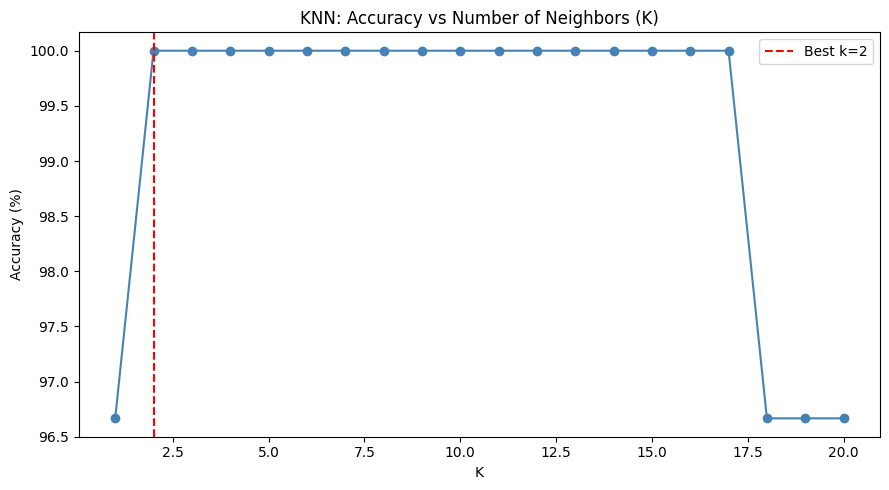

In [4]:
# Find the best value of K
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc * 100)

best_k = k_values[accuracies.index(max(accuracies))]
print(f'Best K value: {best_k} with Accuracy: {max(accuracies):.2f}%')

# Plot accuracy vs K
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('KNN: Accuracy vs Number of Neighbors (K)')
plt.xlabel('K')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()
